6.575 24.0
6.421 21.6
7.185 34.7
6.998 33.4
7.147 36.2
6.43 28.7
6.012 22.9
6.172 27.1
5.631 16.5
6.004 18.9
6.377 15.0
6.009 18.9
5.889 21.7
5.949 20.4
6.096 18.2
5.834 19.9
5.935 23.1
5.99 17.5
5.456 20.2
5.727 18.2


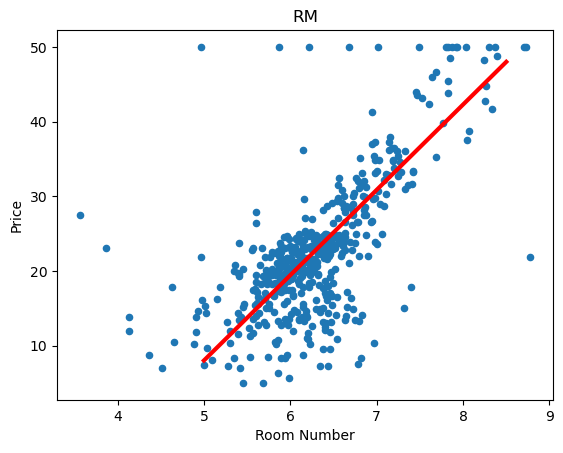

In [14]:
#code-4-1.py
#Visualize the linear relation between the
#number of room and the cost of the house.
import pandas as pd
import numpy as np
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]
# 手动补充特征名
feature_names = np.array([
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM",
    "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"
])

# from sklearn.datasets import load_boston
import matplotlib.pyplot as plt
# dataset = load_boston()
x_data = data # 导入所有特征变量
y_data = target # 导入目标值（房价）
name_data = feature_names #导入特征
plt.subplot(1,1, 1)
plt.scatter(x_data[:,5],y_data,s = 20)
plt.plot([5.,8.5],[8.,48.], color='red',lw=3)
plt.xlabel('Room Number')
plt.ylabel('Price')
plt.title(name_data[5])  
for i in range(0, 20):
    print(x_data[i,5],y_data[i])
plt.show()


[[9.01867888]] [-34.20143988]


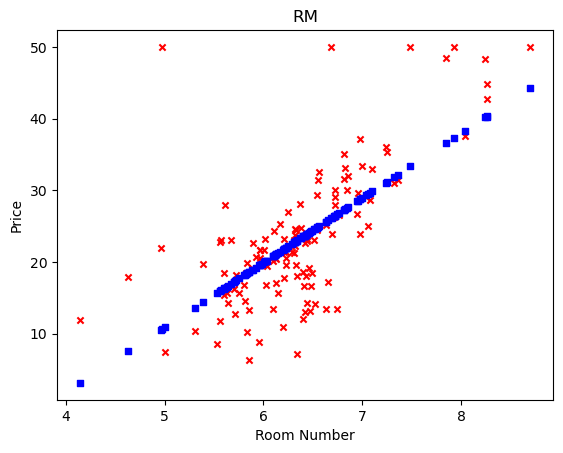

In [15]:
#code-4-2.py
#Simple Linear Regression
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn. model_selection import train_test_split

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]
# 手动补充特征名
feature_names = np.array([
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM",
    "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"
])

x_data = data # 导入所有特征变量
y_data = target # 导入目标值（房价）
name_data = feature_names #导入特征

x_train,x_test,y_train,y_test = train_test_split(x_data, y_data,test_size= 0.25,random_state= 1001)

x_data_train = x_train[:, 5].reshape(-1, 1)#选取前400个样本作为训练集
y_data_train = y_train.reshape(-1, 1)
x_data_test = x_test[:, 5].reshape(-1, 1)#选取剩余的样本作为训练集
y_data_test = y_test.reshape(-1, 1)


simple_model = LinearRegression() #创建线性回归估计器实例
simple_model.fit(x_data_train,y_data_train)#用训练数据拟合模型
y_data_test_p = simple_model.predict(x_data_test)#用训练的模型对测试集进行预测

print(simple_model.coef_, simple_model.intercept_)

plt.subplot(1, 1, 1)
plt.scatter(x_data_test,y_data_test,s = 20, color="r",marker="x")
plt.scatter(x_data_test,y_data_test_p,s = 20, color="b",marker="s")
plt.xlabel('Room Number')
plt.ylabel('Price')
plt.title(name_data[5])  
plt.show()

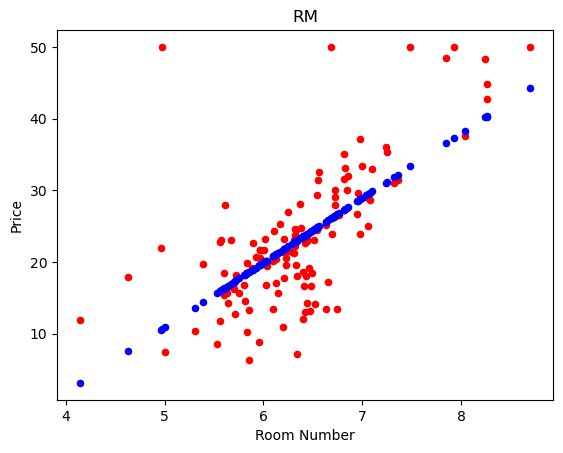

R2
0.46561991850703266


In [16]:
#code-4-3.py
#Simple Linear Regression
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn. model_selection import train_test_split

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]
# 手动补充特征名
feature_names = np.array([
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM",
    "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"
])

x_data = data # 导入所有特征变量
y_data = target # 导入目标值（房价）
name_data = feature_names #导入特征

x_train,x_test,y_train,y_test = train_test_split(x_data, y_data,test_size= 0.25,random_state= 1001)

x_data_train = x_train[:, 5].reshape(-1, 1)#选取前400个样本作为训练集
y_data_train = y_train.reshape(-1, 1)
x_data_test = x_test[:, 5].reshape(-1, 1)#选取剩余的样本作为训练集
y_data_test = y_test.reshape(-1, 1)


simple_model = LinearRegression() #创建线性回归估计器实例
simple_model.fit(x_data_train,y_data_train)#用训练数据拟合模型
y_data_test_p = simple_model.predict(x_data_test)#用训练的模型对测试集进行预测

plt.subplot(1, 1, 1)
plt.scatter(x_data_test,y_data_test,s = 20, color="r")
plt.scatter(x_data_test,y_data_test_p,s = 20, color="b")
plt.xlabel('Room Number')
plt.ylabel('Price')
plt.title(name_data[5])  
plt.show()

r_squared = simple_model.score(x_data_test, y_data_test)
print('R2')
print(r_squared)

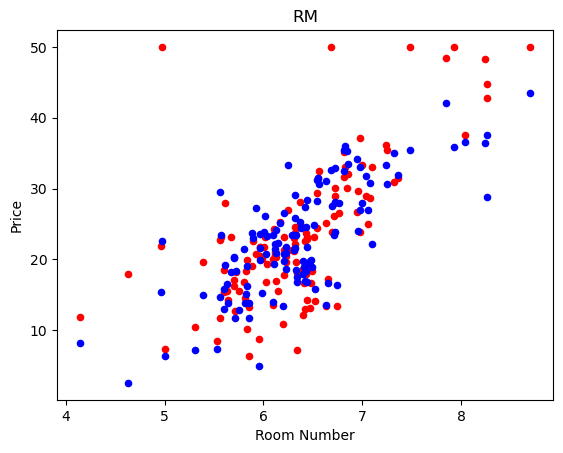

R2 = 0.6783942923302054


In [17]:
#code-4-4.py
#Multiple Linear Regression
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn. model_selection import train_test_split

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]
# 手动补充特征名
feature_names = np.array([
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM",
    "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"
])

x_data = data # 导入所有特征变量
y_data = target # 导入目标值（房价）
name_data = feature_names #导入特征

x_train,x_test,y_train,y_test = train_test_split(x_data, y_data,test_size= 0.25,random_state= 1001)

mlr_model = LinearRegression() #创建线性回归估计器实例
mlr_model.fit(x_train,y_train)#用训练数据拟合模型
y_test_p = mlr_model.predict(x_test)#用训练的模型对测试集进行预测

plt.subplot(1, 1, 1)
plt.scatter(x_test[:,5],y_test,s = 20, color="r")
plt.scatter(x_test[:,5],y_test_p,s = 20, color="b")
plt.xlabel('Room Number')
plt.ylabel('Price')
plt.title(name_data[5])  
plt.show()

r_squared = mlr_model.score(x_test, y_test)
print('R2 = %s' %r_squared )
